# Module 3 — Classification des récifs avec MobileNetV2

Ce notebook entraîne un modèle de transfert d'apprentissage pour classifier les patches ReefNet en quatre catégories :

- `Live_coral`
- `Algae`
- `Substrate_degraded`
- `Other_background`

Le pipeline contient deux phases :

1. entraînement de la tête de classification avec MobileNetV2 gelé ;
2. fine-tuning léger des dernières couches de MobileNetV2.

La séparation train/validation/test a déjà été réalisée par image originale afin d'éviter la fuite de données.

In [1]:
from pathlib import Path
import json
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    accuracy_score,
    balanced_accuracy_score,
    precision_recall_fscore_support
)

import tensorflow as tf
from tensorflow.keras import Model
from tensorflow.keras.layers import (
    Input,
    RandomFlip,
    RandomRotation,
    RandomZoom,
    RandomContrast,
    GlobalAveragePooling2D,
    Dense,
    Dropout
)
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

cwd = Path.cwd()
if (cwd / 'data').exists():
    PROJECT_ROOT = cwd
elif (cwd.parent / 'data').exists():
    PROJECT_ROOT = cwd.parent
else:
    raise FileNotFoundError("Impossible de trouver le dossier data.")

PROCESSED_DIR = PROJECT_ROOT / 'data' / 'processed'
RESULTS_DIR = PROJECT_ROOT / 'results' / 'module3' / 'mobilenetv2'
MODELS_DIR = PROJECT_ROOT / 'models' / 'module3'

RESULTS_DIR.mkdir(parents=True, exist_ok=True)
MODELS_DIR.mkdir(parents=True, exist_ok=True)

TRAIN_CSV = PROCESSED_DIR / 'module3_train.csv'
VAL_CSV = PROCESSED_DIR / 'module3_validation.csv'
TEST_CSV = PROCESSED_DIR / 'module3_test.csv'
METADATA_CSV = PROCESSED_DIR / 'module3_metadata.json'

for path in [TRAIN_CSV, VAL_CSV, TEST_CSV]:
    assert path.exists(), f'Fichier introuvable : {path}'

gpu_devices = tf.config.list_physical_devices('GPU')
print('TensorFlow :', tf.__version__)
print('GPU détecté :', bool(gpu_devices))
print('Racine du projet :', PROJECT_ROOT)

TensorFlow : 2.21.0
GPU détecté : False
Racine du projet : C:\Users\elasr\OneDrive\Desktop\hind


## 1. Chargement des CSV préparés

In [2]:
train_df = pd.read_csv(TRAIN_CSV)
val_df = pd.read_csv(VAL_CSV)
test_df = pd.read_csv(TEST_CSV)

CLASS_NAMES = ['Live_coral', 'Algae', 'Substrate_degraded', 'Other_background']
NUM_CLASSES = len(CLASS_NAMES)

for split_name, split_df in [('train', train_df), ('validation', val_df), ('test', test_df)]:
    assert set(split_df['class_id'].unique()).issubset(set(range(NUM_CLASSES)))
    missing_files = (~split_df['full_path'].map(lambda p: Path(p).exists())).sum()
    print(f'{split_name:10s}: {len(split_df):5d} images | fichiers manquants : {missing_files}')
    assert missing_files == 0, f'Images manquantes dans {split_name}'

display(train_df['ecological_class'].value_counts().reindex(CLASS_NAMES))

train     : 12537 images | fichiers manquants : 0
validation:  2679 images | fichiers manquants : 0
test      :  2654 images | fichiers manquants : 0


ecological_class
Live_coral            3799
Algae                 3987
Substrate_degraded    3195
Other_background      1556
Name: count, dtype: int64

## 2. Création des pipelines `tf.data`

In [3]:
IMG_SIZE = (224, 224)
BATCH_SIZE = 32 if gpu_devices else 16
AUTOTUNE = tf.data.AUTOTUNE

def decode_image(path, label):
    image_bytes = tf.io.read_file(path)
    image = tf.io.decode_image(image_bytes, channels=3, expand_animations=False)
    image.set_shape([None, None, 3])
    image = tf.image.resize(image, IMG_SIZE)
    image = tf.cast(image, tf.float32)
    return image, tf.cast(label, tf.int32)

def make_dataset(dataframe, training=False):
    paths = dataframe['full_path'].astype(str).to_numpy()
    labels = dataframe['class_id'].astype(np.int32).to_numpy()

    dataset = tf.data.Dataset.from_tensor_slices((paths, labels))

    if training:
        dataset = dataset.shuffle(
            buffer_size=min(len(dataframe), 5000),
            seed=SEED,
            reshuffle_each_iteration=True
        )

    dataset = dataset.map(decode_image, num_parallel_calls=AUTOTUNE)
    dataset = dataset.batch(BATCH_SIZE)
    dataset = dataset.prefetch(AUTOTUNE)
    return dataset

train_ds = make_dataset(train_df, training=True)
val_ds = make_dataset(val_df, training=False)
test_ds = make_dataset(test_df, training=False)

print('Taille image :', IMG_SIZE)
print('Batch size :', BATCH_SIZE)

Taille image : (224, 224)
Batch size : 16


## 3. Visualisation d'un batch

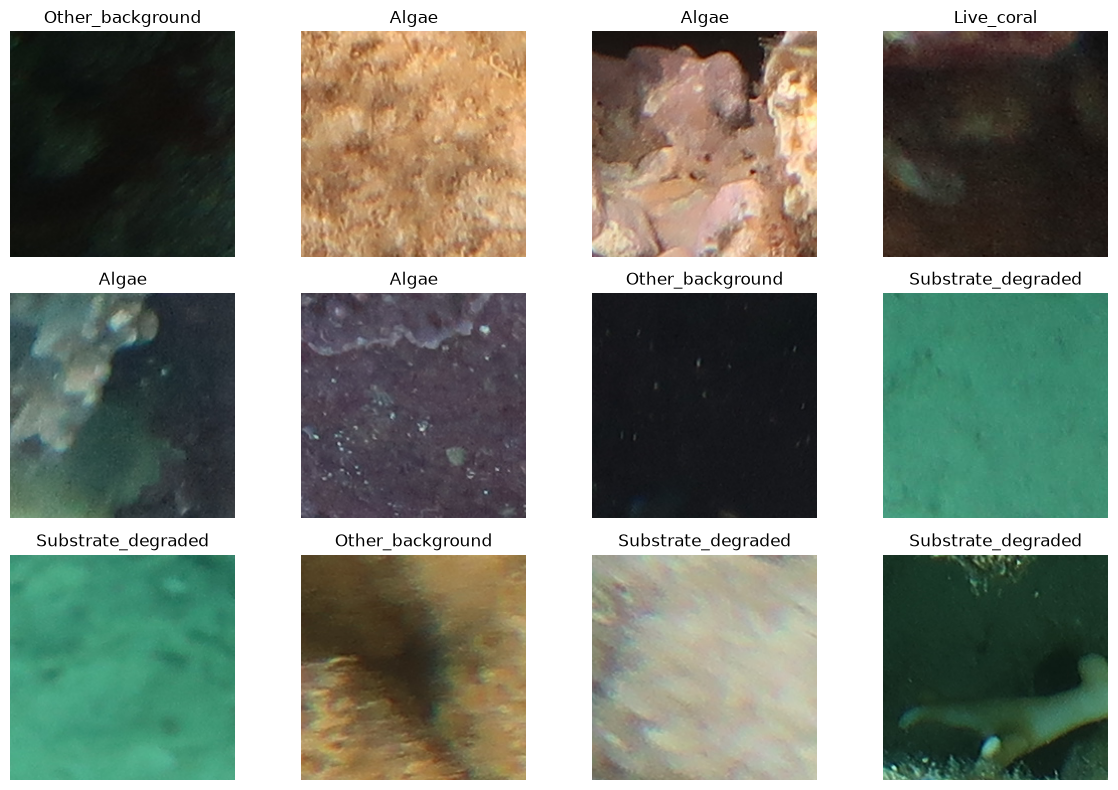

In [4]:
images_batch, labels_batch = next(iter(train_ds))

plt.figure(figsize=(12, 8))
for i in range(min(12, len(images_batch))):
    ax = plt.subplot(3, 4, i + 1)
    plt.imshow(tf.cast(images_batch[i], tf.uint8))
    plt.title(CLASS_NAMES[int(labels_batch[i])])
    plt.axis('off')
plt.tight_layout()
plt.savefig(RESULTS_DIR / 'exemples_train.png', dpi=160, bbox_inches='tight')
plt.show()

## 4. Poids des classes

In [5]:
class_counts = train_df['class_id'].value_counts().sort_index()
total_train = len(train_df)

class_weight = {
    int(class_id): float(total_train / (NUM_CLASSES * count))
    for class_id, count in class_counts.items()
}

for class_id, class_name in enumerate(CLASS_NAMES):
    print(f'{class_id} - {class_name:22s}: {class_weight[class_id]:.4f}')

0 - Live_coral            : 0.8250
1 - Algae                 : 0.7861
2 - Substrate_degraded    : 0.9810
3 - Other_background      : 2.0143


## 5. Construction de MobileNetV2

In [6]:
data_augmentation = tf.keras.Sequential([
    RandomFlip('horizontal'),
    RandomRotation(0.08),
    RandomZoom(0.10),
    RandomContrast(0.10)
], name='data_augmentation')

base_model = MobileNetV2(
    input_shape=IMG_SIZE + (3,),
    include_top=False,
    weights='imagenet'
)
base_model.trainable = False

inputs = Input(shape=IMG_SIZE + (3,), name='image')
x = data_augmentation(inputs)
x = preprocess_input(x)
x = base_model(x, training=False)
x = GlobalAveragePooling2D(name='global_average_pooling')(x)
x = Dropout(0.35)(x)
x = Dense(128, activation='relu', name='dense_features')(x)
x = Dropout(0.25)(x)
outputs = Dense(NUM_CLASSES, activation='softmax', name='predictions')(x)

model = Model(inputs, outputs, name='reefnet_mobilenetv2')

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


Model: "reefnet_mobilenetv2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ image (InputLayer)                   │ (None, 224, 224, 3)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ data_augmentation (Sequential)       │ (None, 224, 224, 3)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ true_divide (TrueDivide)             │ (None, 224, 224, 3)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ subtract (Subtract)                  │ (None, 224, 224, 3)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ mobilenetv2_1.00_224 (Functional)    │ (None, 7, 7, 1280)          │       2,257,984 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ global_average_pooling               │ (None, 1280)                │               0 │
│ (GlobalAveragePooling2D)             │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 1280)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_features (Dense)               │ (None, 128)                 │         163,968 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ predictions (Dense)                  │ (None, 4)                   │             516 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 2,422,468 (9.24 MB)

 Trainable params: 164,484 (642.52 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

## 6. Phase 1 — Entraînement de la tête de classification

In [7]:
PHASE1_MODEL_PATH = MODELS_DIR / 'module3_mobilenetv2_phase1_best.keras'

phase1_callbacks = [
    ModelCheckpoint(
        PHASE1_MODEL_PATH,
        monitor='val_loss',
        save_best_only=True,
        verbose=1
    ),
    EarlyStopping(
        monitor='val_loss',
        patience=5,
        restore_best_weights=True,
        verbose=1
    ),
    ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=2,
        min_lr=1e-6,
        verbose=1
    )
]

history_phase1 = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=15,
    class_weight=class_weight,
    callbacks=phase1_callbacks,
    verbose=1
)

Epoch 1/15
784/784 ━━━━━━━━━━━━━━━━━━━━ 0s 324ms/step - accuracy: 0.5380 - loss: 1.1024
Epoch 1: val_loss improved from None to 0.91500, saving model to C:\Users\elasr\OneDrive\Desktop\hind\models\module3\module3_mobilenetv2_phase1_best.keras

Epoch 1: finished saving model to C:\Users\elasr\OneDrive\Desktop\hind\models\module3\module3_mobilenetv2_phase1_best.keras
784/784 ━━━━━━━━━━━━━━━━━━━━ 310s 385ms/step - accuracy: 0.5908 - loss: 0.9851 - val_accuracy: 0.6353 - val_loss: 0.9150 - learning_rate: 0.0010
Epoch 2/15
784/784 ━━━━━━━━━━━━━━━━━━━━ 0s 292ms/step - accuracy: 0.6155 - loss: 0.9084
Epoch 2: val_loss improved from 0.91500 to 0.82213, saving model to C:\Users\elasr\OneDrive\Desktop\hind\models\module3\module3_mobilenetv2_phase1_best.keras

Epoch 2: finished saving model to C:\Users\elasr\OneDrive\Desktop\hind\models\module3\module3_mobilenetv2_phase1_best.keras
784/784 ━━━━━━━━━━━━━━━━━━━━ 271s 345ms/step - accuracy: 0.6300 - loss: 0.8864 - val_accuracy: 0.6850 - val_loss: 0.

## 7. Phase 2 — Fine-tuning léger

In [8]:
base_model.trainable = True

# On ne déverrouille que les 30 dernières couches.
for layer in base_model.layers[:-30]:
    layer.trainable = False

# Les couches BatchNormalization restent gelées pour stabiliser le fine-tuning.
for layer in base_model.layers:
    if isinstance(layer, tf.keras.layers.BatchNormalization):
        layer.trainable = False

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

FINAL_MODEL_PATH = MODELS_DIR / 'module3_mobilenetv2_final.keras'

phase2_callbacks = [
    ModelCheckpoint(
        FINAL_MODEL_PATH,
        monitor='val_loss',
        save_best_only=True,
        verbose=1
    ),
    EarlyStopping(
        monitor='val_loss',
        patience=4,
        restore_best_weights=True,
        verbose=1
    ),
    ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=2,
        min_lr=1e-7,
        verbose=1
    )
]

history_phase2 = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=10,
    class_weight=class_weight,
    callbacks=phase2_callbacks,
    verbose=1
)

Epoch 1/10
784/784 ━━━━━━━━━━━━━━━━━━━━ 0s 411ms/step - accuracy: 0.6704 - loss: 0.7846
Epoch 1: val_loss improved from None to 0.82272, saving model to C:\Users\elasr\OneDrive\Desktop\hind\models\module3\module3_mobilenetv2_final.keras

Epoch 1: finished saving model to C:\Users\elasr\OneDrive\Desktop\hind\models\module3\module3_mobilenetv2_final.keras
784/784 ━━━━━━━━━━━━━━━━━━━━ 383s 474ms/step - accuracy: 0.6734 - loss: 0.7867 - val_accuracy: 0.6697 - val_loss: 0.8227 - learning_rate: 1.0000e-05
Epoch 2/10
784/784 ━━━━━━━━━━━━━━━━━━━━ 0s 330ms/step - accuracy: 0.6714 - loss: 0.7779
Epoch 2: val_loss improved from 0.82272 to 0.79787, saving model to C:\Users\elasr\OneDrive\Desktop\hind\models\module3\module3_mobilenetv2_final.keras

Epoch 2: finished saving model to C:\Users\elasr\OneDrive\Desktop\hind\models\module3\module3_mobilenetv2_final.keras
784/784 ━━━━━━━━━━━━━━━━━━━━ 306s 389ms/step - accuracy: 0.6821 - loss: 0.7604 - val_accuracy: 0.6797 - val_loss: 0.7979 - learning_rate

## 8. Courbes d'apprentissage

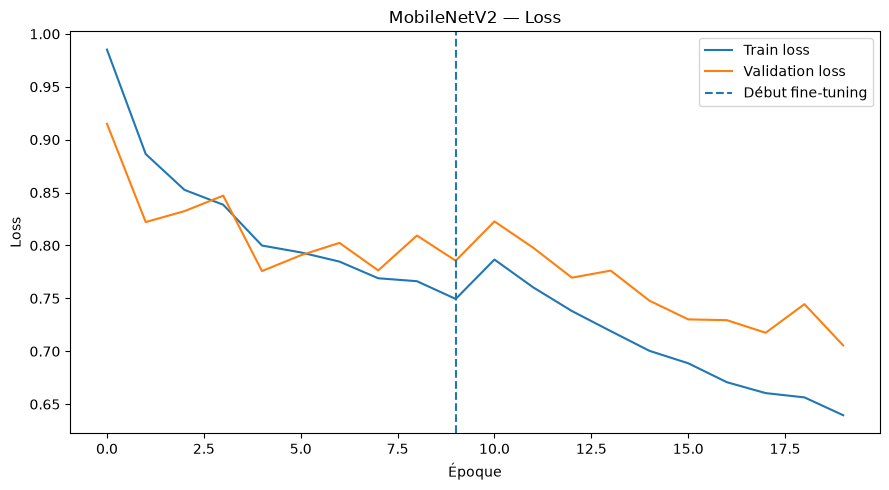

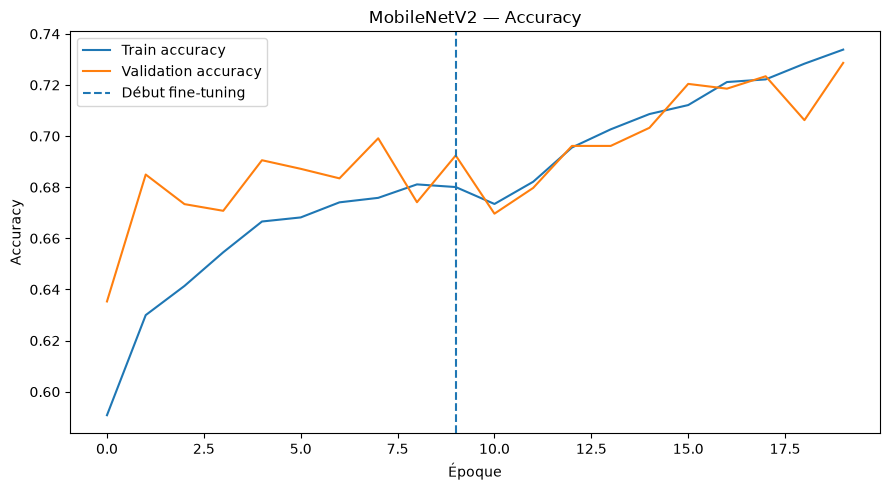

In [9]:
train_loss = history_phase1.history['loss'] + history_phase2.history['loss']
val_loss = history_phase1.history['val_loss'] + history_phase2.history['val_loss']
train_acc = history_phase1.history['accuracy'] + history_phase2.history['accuracy']
val_acc = history_phase1.history['val_accuracy'] + history_phase2.history['val_accuracy']

fine_tune_start = len(history_phase1.history['loss'])

plt.figure(figsize=(9, 5))
plt.plot(train_loss, label='Train loss')
plt.plot(val_loss, label='Validation loss')
plt.axvline(fine_tune_start - 1, linestyle='--', label='Début fine-tuning')
plt.title('MobileNetV2 — Loss')
plt.xlabel('Époque')
plt.ylabel('Loss')
plt.legend()
plt.tight_layout()
plt.savefig(RESULTS_DIR / 'training_loss.png', dpi=160, bbox_inches='tight')
plt.show()

plt.figure(figsize=(9, 5))
plt.plot(train_acc, label='Train accuracy')
plt.plot(val_acc, label='Validation accuracy')
plt.axvline(fine_tune_start - 1, linestyle='--', label='Début fine-tuning')
plt.title('MobileNetV2 — Accuracy')
plt.xlabel('Époque')
plt.ylabel('Accuracy')
plt.legend()
plt.tight_layout()
plt.savefig(RESULTS_DIR / 'training_accuracy.png', dpi=160, bbox_inches='tight')
plt.show()

## 9. Évaluation sur le jeu de test

In [10]:
best_model = tf.keras.models.load_model(FINAL_MODEL_PATH)

test_loss, test_accuracy = best_model.evaluate(test_ds, verbose=1)
probabilities = best_model.predict(test_ds, verbose=1)
predictions = probabilities.argmax(axis=1)
true_labels = test_df['class_id'].to_numpy(dtype=np.int32)

precision_macro, recall_macro, f1_macro, _ = precision_recall_fscore_support(
    true_labels,
    predictions,
    average='macro',
    zero_division=0
)

metrics = {
    'test_loss': float(test_loss),
    'accuracy': float(accuracy_score(true_labels, predictions)),
    'balanced_accuracy': float(balanced_accuracy_score(true_labels, predictions)),
    'macro_precision': float(precision_macro),
    'macro_recall': float(recall_macro),
    'macro_f1': float(f1_macro)
}

print('Métriques finales :')
for key, value in metrics.items():
    print(f'{key:20s}: {value:.4f}')

report = classification_report(
    true_labels,
    predictions,
    target_names=CLASS_NAMES,
    digits=4,
    zero_division=0,
    output_dict=True
)

report_df = pd.DataFrame(report).transpose()
display(report_df)

report_df.to_csv(
    RESULTS_DIR / 'classification_report.csv',
    encoding='utf-8-sig'
)

(RESULTS_DIR / 'metrics.json').write_text(
    json.dumps(metrics, ensure_ascii=False, indent=2),
    encoding='utf-8'
)

166/166 ━━━━━━━━━━━━━━━━━━━━ 47s 259ms/step - accuracy: 0.7087 - loss: 0.7226
166/166 ━━━━━━━━━━━━━━━━━━━━ 48s 275ms/step
Métriques finales :
test_loss           : 0.7226
accuracy            : 0.7087
balanced_accuracy   : 0.7069
macro_precision     : 0.6900
macro_recall        : 0.7069
macro_f1            : 0.6965


,precision,recall,f1-score,support
Live_coral,0.785714,0.750000,0.767442,792.000000
Algae,0.719321,0.667070,0.692211,826.000000
Substrate_degraded,0.683879,0.716359,0.699742,758.000000
Other_background,0.571006,0.694245,0.626623,278.000000
accuracy,0.708742,0.708742,0.708742,0.708742
macro avg,0.689980,0.706918,0.696505,2654.000000
weighted avg,0.713476,0.708742,0.709942,2654.000000


226

<Figure size 800x700 with 0 Axes>

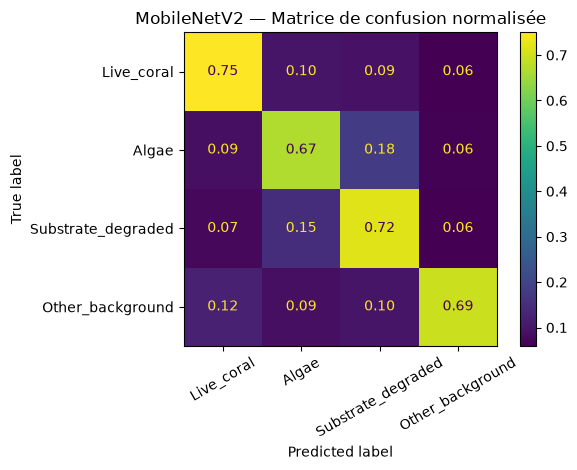

<Figure size 800x700 with 0 Axes>

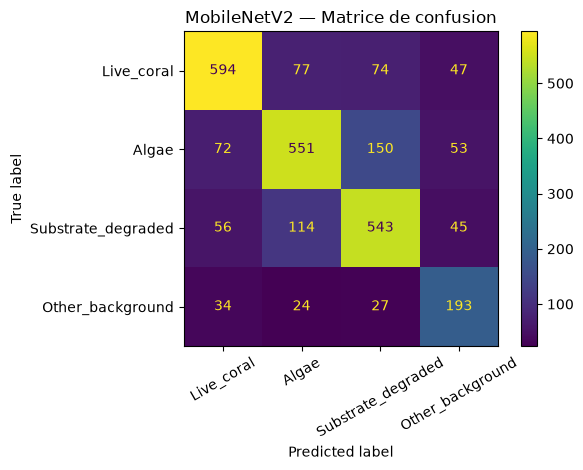

In [11]:
plt.figure(figsize=(8, 7))
ConfusionMatrixDisplay.from_predictions(
    true_labels,
    predictions,
    display_labels=CLASS_NAMES,
    normalize='true',
    values_format='.2f',
    xticks_rotation=30
)
plt.title('MobileNetV2 — Matrice de confusion normalisée')
plt.tight_layout()
plt.savefig(
    RESULTS_DIR / 'confusion_matrix_normalized.png',
    dpi=160,
    bbox_inches='tight'
)
plt.show()

plt.figure(figsize=(8, 7))
ConfusionMatrixDisplay.from_predictions(
    true_labels,
    predictions,
    display_labels=CLASS_NAMES,
    values_format='d',
    xticks_rotation=30
)
plt.title('MobileNetV2 — Matrice de confusion')
plt.tight_layout()
plt.savefig(
    RESULTS_DIR / 'confusion_matrix_counts.png',
    dpi=160,
    bbox_inches='tight'
)
plt.show()

## 10. Sauvegarde des prédictions et métadonnées

In [12]:
predictions_df = test_df.copy()
predictions_df['predicted_class_id'] = predictions
predictions_df['predicted_class'] = [CLASS_NAMES[i] for i in predictions]
predictions_df['confidence'] = probabilities.max(axis=1)

for class_id, class_name in enumerate(CLASS_NAMES):
    predictions_df[f'prob_{class_name}'] = probabilities[:, class_id]

predictions_df.to_csv(
    RESULTS_DIR / 'test_predictions.csv',
    index=False,
    encoding='utf-8-sig'
)

metadata = {
    'model': 'MobileNetV2',
    'image_size': list(IMG_SIZE),
    'class_names': CLASS_NAMES,
    'class_to_id': {name: idx for idx, name in enumerate(CLASS_NAMES)},
    'preprocessing': 'mobilenet_v2.preprocess_input',
    'split_strategy': 'grouped by original_image_id',
    'train_size': int(len(train_df)),
    'validation_size': int(len(val_df)),
    'test_size': int(len(test_df)),
    'metrics': metrics,
    'limitation': (
        'The source dataset is named ReefNet RSG TestDataset and was reorganized '
        'as a proof of concept.'
    )
}

metadata_path = MODELS_DIR / 'module3_metadata.json'
metadata_path.write_text(
    json.dumps(metadata, ensure_ascii=False, indent=2),
    encoding='utf-8'
)

print('✅ Modèle final :', FINAL_MODEL_PATH)
print('✅ Métadonnées :', metadata_path)
print('✅ Résultats :', RESULTS_DIR)

✅ Modèle final : C:\Users\elasr\OneDrive\Desktop\hind\models\module3\module3_mobilenetv2_final.keras
✅ Métadonnées : C:\Users\elasr\OneDrive\Desktop\hind\models\module3\module3_metadata.json
✅ Résultats : C:\Users\elasr\OneDrive\Desktop\hind\results\module3\mobilenetv2


## Fichiers attendus

Dans `models/module3/` :

- `module3_mobilenetv2_final.keras`
- `module3_metadata.json`

Dans `results/module3/mobilenetv2/` :

- courbes d'apprentissage ;
- matrices de confusion ;
- rapport de classification ;
- métriques finales ;
- prédictions du jeu de test.

L'étape suivante sera la génération des cartes Grad-CAM et le calcul de l'état écologique global par image originale.